## <center>Enhancing Customer Churn Prediction: A Hybrid Stacking Model Using Random Forest and XGBoost</center>

**Stacking** is an ensemble learning technique that **combines multiple machine learning models to improve prediction accuracy**. Instead of relying on a single model, stacking trains base models separately, then feeds their predictions as inputs to a meta-model **(Logistic Regression)**. The meta-model learns how to best combine the base models' outputs, leveraging their strengths while minimizing weaknesses. **Random Forest** is robust against overfitting and handles categorical data well, while **XGBoost** is highly efficient and excels in capturing complex patterns. **By stacking them, we leverage their strengths and compensate for individual weaknesses, creating a more accurate and generalizable model.**

### Data Pre-processing

#### Importing Libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# Set plotting style
sns.set_theme(style="whitegrid")

#### Loading the Dataset

In [2]:
# Load Data
dataset = pd.read_csv("Churn_Modelling.csv")
dataset

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
# Create a tracker dataframe to preserve IDs and Surnames for later
customer_tracker = dataset[['CustomerId', 'Surname']].copy()

#### Dropping Unnecessary Columns

In [4]:
# Initialize LabelEncoder for binary features
label_encoder = LabelEncoder()

# Label encode Gender (binary - safe)
dataset["Gender"] = label_encoder.fit_transform(dataset["Gender"])

# One-Hot Encode Geography 
# This handles France, Germany, and Spain correctly without implying one is 'better' than the other.
dataset = pd.get_dummies(dataset, columns=["Geography"], drop_first=True)

# Keep RowNumber out as well if you don't need it, but keep CustomerId and Surname
if "RowNumber" in dataset.columns:
    dataset = dataset.drop(columns=["RowNumber"])

## Feature Engineering

Two additional features are constructed to provide the model with richer, more structured signals beyond the raw dataset.

- **AgeGroup** bins the continuous Age variable into five categories — Young Adults (18–30), Early Middle-Age (31–40), Mid-Life Adults (41–50), Pre-Retirement (51–60), and Retirees & Seniors (61+) — and is cast to integer to ensure compatibility across both models. This captures segment-level patterns that a continuous age variable may spread too thinly across.
- **BalanceSalaryRatio (BSR)** expresses a customer's account balance relative to their estimated salary. Two customers with identical balances but very different salaries occupy meaningfully different financial positions, and BSR makes this distinction explicit. Values are capped at the 99th percentile to prevent customers with very low salaries from producing extreme outliers that could distort model predictions. Infinite and missing values are removed as a final cleaning step.

#### Creating Age Group and Balance-to-Salary Ratio Features

In [5]:
# Create Age Group Feature and cast to int to avoid dtype issues
dataset["AgeGroup"] = pd.cut(dataset["Age"], bins=[18, 30, 40, 50, 60, 100], 
                             labels=[0, 1, 2, 3, 4], include_lowest=True).astype(int)

# Balance-to-Salary Ratio Feature
dataset["BalanceSalaryRatio"] = dataset["Balance"] / (dataset["EstimatedSalary"] + 1)

# Fix: Cap extreme outliers at 99th percentile
bsr_cap = dataset["BalanceSalaryRatio"].quantile(0.99)
dataset["BalanceSalaryRatio"] = dataset["BalanceSalaryRatio"].clip(upper=bsr_cap)

# Handle Infinite/NaN Values
dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
dataset.dropna(inplace=True)

In [6]:
# Verify the mapping of ages to age groups
age_mapping = dataset.groupby("AgeGroup")["Age"].unique()
age_mapping_dict = {group: list(ages) for group, ages in age_mapping.items()}

# Print the mapped values
for group, ages in age_mapping_dict.items():
    print(f"Age Group {group}: {ages}")

Age Group 0: [29, 27, 24, 25, 19, 26, 21, 22, 30, 28, 20, 23, 18]
Age Group 1: [39, 31, 34, 35, 32, 38, 36, 33, 40, 37]
Age Group 2: [42, 41, 43, 44, 50, 45, 46, 49, 48, 47]
Age Group 3: [58, 51, 56, 55, 52, 57, 54, 53, 59, 60]
Age Group 4: [61, 66, 75, 65, 73, 72, 67, 79, 62, 80, 68, 70, 63, 64, 82, 69, 74, 71, 76, 77, 88, 85, 84, 78, 81, 92, 83]


> #### Age Group Categories Guide:
> - **Age Group 0 (18-30):** Young Adults
> - **Age Group 1 (31-40):** Early Middle-Age
> - **Age Group 2 (41-50):** Mid-Life Adults
> - **Age Group 3 (51-60):** Pre-Retirement
> - **Age Group 4 (61-92):** Retirees & Seniors

> #### Balance-to-Salary Ratio (BSR) Guide:
> - **Low BSR (≤ 0.1):** High churn risk — the customer may be financially unstable or less engaged with the bank.
> - **Moderate BSR (0.1 – 1.0):** Churn likelihood may depend on engagement level and product offerings.
> - **High BSR (> 1.0):** Low churn risk — the customer relies on the bank as a savings vehicle.

> **Note:** BSR values are capped at the 99th percentile to prevent extreme outliers from distorting model predictions. Customers with very low estimated salaries could otherwise produce disproportionately large BSR values that do not reflect genuine financial behavior.

In [7]:
# --- STEP 1: DEFINE X (Features) AND y (Target) ---

# X includes everything EXCEPT the target and IDs
X = dataset.drop(columns=["Exited", "CustomerId", "Surname", "RowNumber"], errors='ignore')

# y is ONLY the target column 'Exited'
y = dataset["Exited"]

# --- STEP 2: NOW RUN THE SPLIT ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Stacking Ensemble Machine Learning

Stacking combines multiple base models by using their predictions as inputs to a meta-model, which learns how to best blend their outputs. This implementation follows a structured pipeline:

- **Model 1 — Random Forest** builds multiple decision trees and aggregates their predictions to improve accuracy and reduce overfitting. It is configured with `class_weight="balanced"` to account for the unequal distribution of churned and retained customers in the dataset.
- **Model 2 — XGBoost** uses gradient boosting to sequentially correct prediction errors, excelling at capturing complex, non-linear patterns. It is configured with `scale_pos_weight` — computed from the actual class ratio in the training set — to give appropriate weight to the minority churn class.
- **Out-of-Fold (OOF) Predictions** are generated for both base models using 5-fold cross-validation. Each fold is predicted by a model that was never trained on it, producing honest and unbiased probability estimates that serve as inputs to the meta-model.
- **Meta-Feature Scaling** is applied using `StandardScaler` before training the meta-model, ensuring the Logistic Regression receives consistently scaled inputs.
- **Logistic Regression Meta-Model** is trained on the scaled OOF predictions, learning the optimal blend of both base models' outputs into a final churn probability. Base models are then retrained on the full training set, and their test set predictions are scaled using the same fitted scaler before final evaluation.

In [8]:
# 1. Initialize Base Models with Class Imbalance Fixes
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight="balanced")

neg, pos = np.bincount(y_train)
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, 
                          eval_metric="logloss", scale_pos_weight=neg/pos)

# 2. Generate Out-of-Fold Predictions (Fixes Data Leakage)
print("Generating Out-of-Fold predictions...")
rf_oof = cross_val_predict(rf_model, X_train, y_train, cv=5, method="predict_proba")[:, 1]
xgb_oof = cross_val_predict(xgb_model, X_train.astype(float), y_train, cv=5, method="predict_proba")[:, 1]

# 3. Create and Scale Meta-Features
X_train_meta = np.column_stack((rf_oof, xgb_oof))
scaler = StandardScaler()
X_train_meta_scaled = scaler.fit_transform(X_train_meta)

# 4. Train Meta-Model
meta_model = LogisticRegression()
meta_model.fit(X_train_meta_scaled, y_train)

# 5. Final Base Model Training for Testing
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train.astype(float), y_train)

# 6. Prepare Scaled Meta-Test Set
X_test_meta = np.column_stack((
    rf_model.predict_proba(X_test)[:, 1],
    xgb_model.predict_proba(X_test.astype(float))[:, 1]
))
X_test_meta_scaled = scaler.transform(X_test_meta)

Generating Out-of-Fold predictions...


### Model Validation

In [9]:
# Cross-Validation Accuracy (Using scaled OOF data)
cv_scores = cross_val_score(meta_model, X_train_meta_scaled, y_train, cv=5, scoring="accuracy")
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Final Predictions
stacked_preds = meta_model.predict(X_test_meta_scaled)
print(f"Stacked Model Accuracy: {accuracy_score(y_test, stacked_preds):.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, stacked_preds))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, stacked_preds))

Cross-Validation Accuracy: 0.8567 ± 0.0063
Stacked Model Accuracy: 0.8640

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1607
           1       0.71      0.53      0.60       393

    accuracy                           0.86      2000
   macro avg       0.80      0.74      0.76      2000
weighted avg       0.85      0.86      0.86      2000


Confusion Matrix:
[[1520   87]
 [ 185  208]]


> The model is evaluated using **Out-of-Fold (OOF) predictions**, where each fold is tested on data the base models have never seen during training. This ensures the cross-validation accuracy reflects honest generalization performance. A close alignment between CV accuracy and test accuracy confirms that the stacking architecture generalizes well to unseen data.

> The stacked model benefits from two design choices that improve churn detection: OOF-based stacking ensures unbiased meta-features, and scale_pos_weight in XGBoost accounts for the natural class imbalance in churn datasets. As a result, the model is better calibrated across both classes. The stacked model performs well in predicting **customer retention** but is less confident in identifying those who will churn. This means it is **effective in most cases but may occasionally miss some customers who are likely to leave**. Overall, the model provides useful insights for predicting churn, and its performance is strong for a straightforward prediction approach.

In [10]:
# 1. Prepare Features for Prediction
# We use X.columns to ensure we grab ONLY the exact features the model was trained on
X_final_features = dataset[X.columns].copy()

# 2. Generate Base Probabilities
rf_probs = rf_model.predict_proba(X_final_features)[:, 1]
xgb_probs = xgb_model.predict_proba(X_final_features.astype(float))[:, 1]

# 3. Apply Scaling and Meta-Model for Final Churn Probability
X_meta_scaled = scaler.transform(np.column_stack((rf_probs, xgb_probs)))
dataset["Churn_Probability"] = meta_model.predict_proba(X_meta_scaled)[:, 1]

# 4. RECODE DATA: Reconstruct original readable columns
# Double-run protection: Only map if the column is still numeric (int or float)

# Recode Gender
if dataset["Gender"].dtype != 'object':
    dataset["Gender"] = dataset["Gender"].map({0: "Female", 1: "Male"})

# Recode Binary Columns
if dataset["HasCrCard"].dtype != 'object':
    dataset["HasCrCard"] = dataset["HasCrCard"].map({0: "No", 1: "Yes"})

if dataset["IsActiveMember"].dtype != 'object':
    dataset["IsActiveMember"] = dataset["IsActiveMember"].map({0: "No", 1: "Yes"})

# NEW: Recode AgeGroup back to original descriptive labels
if dataset["AgeGroup"].dtype != 'object':
    age_group_labels = {
        0: "Young Adults (18-30)",
        1: "Early Middle-Age (31-40)",
        2: "Mid-Life Adults (41-50)",
        3: "Pre-Retirement (51-60)",
        4: "Retirees & Seniors (61+)"
    }
    dataset["AgeGroup"] = dataset["AgeGroup"].map(age_group_labels)

# Reconstruct Geography label from One-Hot columns
if "Geography_Germany" in dataset.columns:
    def decode_geography(row):
        if row.get("Geography_Germany", 0) == 1: return "Germany"
        if row.get("Geography_Spain", 0) == 1: return "Spain"
        return "France"
    dataset["Geography"] = dataset.apply(decode_geography, axis=1)

# 5. Ensure IDs and Surnames are present from the tracker
dataset['CustomerId'] = customer_tracker['CustomerId']
dataset['Surname'] = customer_tracker['Surname']

# 6. Reorder and Display the Full Dataframe
full_display_cols = [
    "CustomerId", "Surname", "Geography", "Gender", "Age", "AgeGroup",
    "CreditScore", "Balance", "EstimatedSalary", "BalanceSalaryRatio",
    "Tenure", "NumOfProducts", "HasCrCard", "IsActiveMember", 
    "Exited", "Churn_Probability"
]

# Create the final view and sort by high risk
final_complete_df = dataset[full_display_cols].sort_values(by="Churn_Probability", ascending=False)

# Display the top 10 rows
print("FULL DATASET & CHURN PROBABILITIES:")
final_complete_df.head(10)

FULL DATASET & CHURN PROBABILITIES:


,CustomerId,Surname,Geography,Gender,Age,AgeGroup,CreditScore,Balance,EstimatedSalary,BalanceSalaryRatio,Tenure,NumOfProducts,HasCrCard,IsActiveMember,Exited,Churn_Probability
1265,15662291,Davidson,France,Female,55,Pre-Retirement (51-60),534,116973.26,122066.50,0.958267,8,3,Yes,No,1,0.908525
8923,15570002,Burlingame,Germany,Female,55,Pre-Retirement (51-60),625,118772.71,135853.62,0.874263,8,4,No,No,1,0.907962
2614,15640846,Chibueze,Germany,Female,58,Pre-Retirement (51-60),546,106458.31,128881.87,0.826008,3,4,Yes,No,1,0.907560
1657,15752342,Bradley,Germany,Female,54,Pre-Retirement (51-60),704,133656.91,145071.33,0.921312,6,3,Yes,No,1,0.906921
4013,15653776,Salier,Germany,Female,57,Pre-Retirement (51-60),720,162082.31,27145.73,5.970602,1,4,No,No,1,0.906490
1962,15692416,Aikenhead,Spain,Female,52,Pre-Retirement (51-60),358,143542.36,141959.11,1.011146,8,3,Yes,No,1,0.905948
6911,15710087,Nicholls,Germany,Female,54,Pre-Retirement (51-60),705,125889.30,96013.50,1.311149,3,3,Yes,No,1,0.905840
4992,15783019,Price,France,Female,62,Retirees & Seniors (61+),794,123681.32,173586.63,0.712501,9,3,Yes,No,1,0.904459
70,15703793,Konovalova,Germany,Male,58,Pre-Retirement (51-60),738,133745.44,28373.86,4.713519,2,4,Yes,No,1,0.903517
9438,15641175,Munro,Germany,Male,63,Retirees & Seniors (61+),701,120916.52,144727.45,0.835472,3,3,No,No,1,0.902528


---

## Feature Importance

#### Random Forest

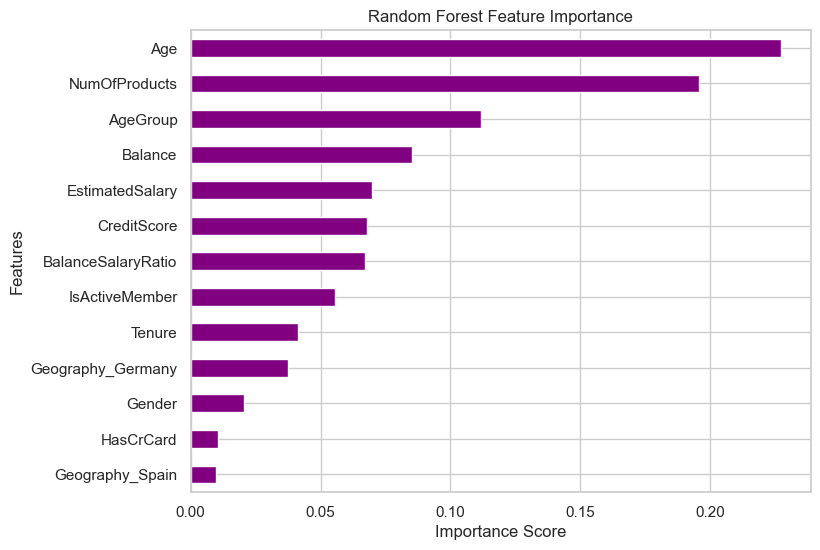

In [11]:
# Feature Importance for Random Forest
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
rf_importance.sort_values(ascending=True).plot(kind="barh", title="Random Forest Feature Importance", figsize=(8, 6), color="purple")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

> The Random Forest feature importance highlights Age, NumOfProducts, and AgeGroup as the most influential features in predicting customer churn. **Age** is the most significant factor, suggesting that customer retention varies by age. **NumOfProducts** follows closely, indicating that the number of products a customer holds strongly impacts their likelihood of leaving. **AgeGroup** ranks third, reinforcing that age-based segmentation plays a key role in churn prediction.

#### XGBoost

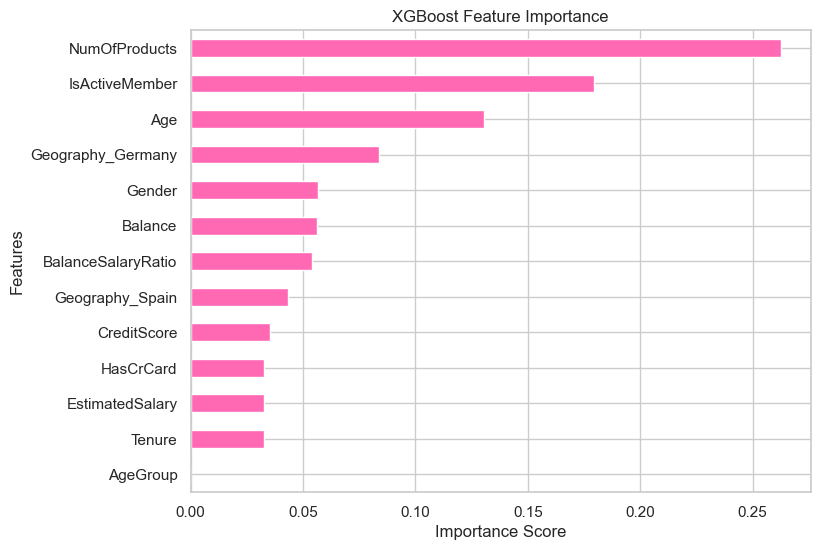

In [12]:
# Feature Importance for XGBoost
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
xgb_importance.sort_values(ascending=True).plot(kind="barh", title="XGBoost Feature Importance", figsize=(8, 6), color="hotpink")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

> The XGBoost feature importance results highlight **NumOfProducts**, **IsActiveMember**, and **Age** as the top predictors of customer churn. Notably, **AgeGroup** is missing, likely because XGBoost found the raw Age feature more informative. Since AgeGroup is a categorized version, the model likely ignored it in favor of the more precise numerical data.

#### Feature Importance for Both Models

Random Forest and XGBoost determine feature importance differently. Random Forest calculates importance based on how much a feature reduces impurity across all decision trees. It tends to spread importance across correlated features, which is why both Age and AgeGroup received rankings. On the other hand, XGBoost uses boosting and assigns importance based on how much a feature improves model performance, often dropping redundant features. In this case, XGBoost ranked Age highly but ignored AgeGroup, likely because Age provided enough information, making AgeGroup unnecessary. This highlights how Random Forest retains more correlated features, while XGBoost is more selective in feature ranking.

---

## Rank Averaging for Feature Importance Aggregation

To create a balanced final ranking where the importance rankings from both models are averaged, this simple yet effective ensemble feature selection technique helps mitigate differences in how models calculate importance and ensures that no single model disproportionately influences feature selection.

This process extracts **feature importance scores** from both **Random Forest** and **XGBoost**, merges them, and calculates the average importance for each feature. It then sorts the features based on their average importance scores, ensuring a balanced evaluation from both models. 

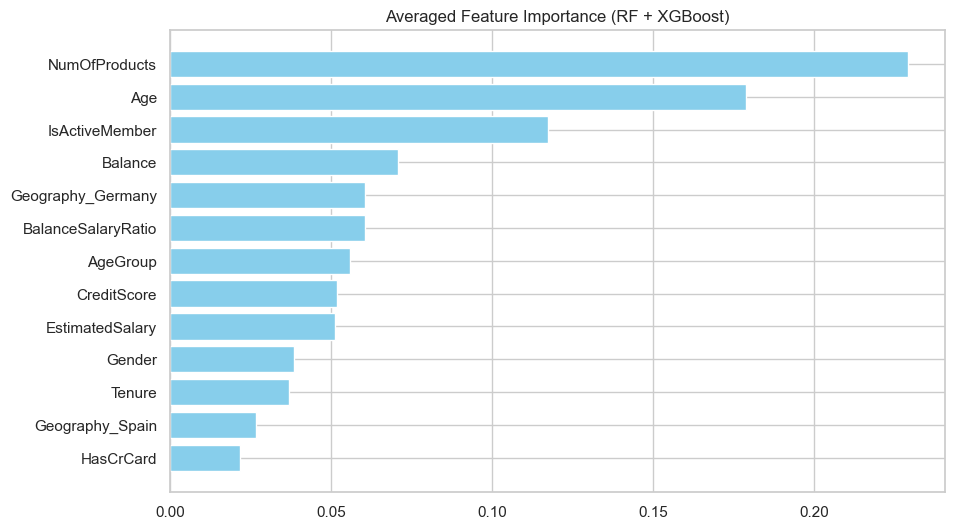

               Feature  Avg_Importance
5        NumOfProducts        0.229241
2                  Age        0.178811
7       IsActiveMember        0.117397
4              Balance        0.070831
9    Geography_Germany        0.060651
12  BalanceSalaryRatio        0.060458
11            AgeGroup        0.055949
0          CreditScore        0.051663
8      EstimatedSalary        0.051337
1               Gender        0.038560
3               Tenure        0.036955
10     Geography_Spain        0.026567
6            HasCrCard        0.021579


In [13]:
# Get feature importance from base models
rf_importance_df = pd.DataFrame({'Feature': X.columns, 'RF_Importance': rf_model.feature_importances_})
xgb_importance_df = pd.DataFrame({'Feature': X.columns, 'XGB_Importance': xgb_model.feature_importances_})

# Merge and Compute Average
importance_df = rf_importance_df.merge(xgb_importance_df, on="Feature")
importance_df["Avg_Importance"] = (importance_df["RF_Importance"] + importance_df["XGB_Importance"]) / 2
importance_df = importance_df.sort_values(by="Avg_Importance", ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Avg_Importance"], color="skyblue")
plt.title("Averaged Feature Importance (RF + XGBoost)")
plt.show()

print(importance_df[['Feature', 'Avg_Importance']].sort_values(by="Avg_Importance", ascending=False))

> The averaged importance consensus across both models identifies **NumOfProducts**, **Age**, and **IsActiveMember** as the strongest predictors, indicating that product holdings, life stage, and account activity are the most differentiating factors. **Balance** and **BalanceSalaryRatio** carry moderate influence, reflecting that a customer's financial standing is associated with churn patterns. **Geography_Germany** shows a more distinct churn pattern relative to the French baseline, while **Geography_Spain** shows a weaker but present distinction. **AgeGroup**, **CreditScore**, and **EstimatedSalary** contribute modestly, capturing supplementary demographic and financial signals. **Gender**, **Tenure**, and **HasCrCard** rank lowest, indicating that gender, relationship length, and credit card ownership are weak predictors in this dataset.